Detected columns: ['green', 'Unnamed: 1', 'green-dashed', 'Unnamed: 3', 'orange', 'Unnamed: 5', 'orange-dashed', 'Unnamed: 7', 'red', 'Unnamed: 9', 'red-dashed', 'Unnamed: 11', 'black', 'Unnamed: 13']


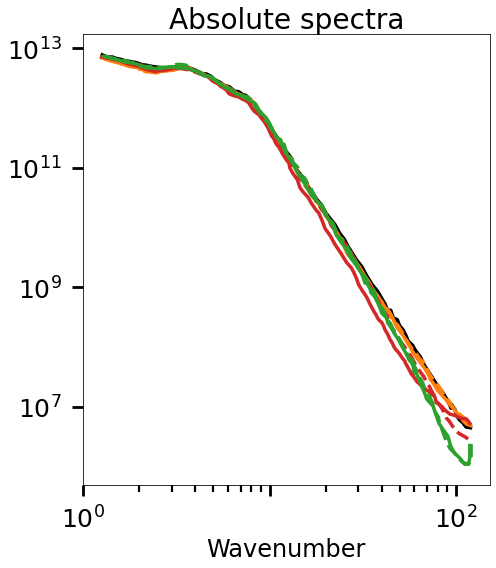

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter, LogLocator, FuncFormatter

# ------------------------------------------------------------
# STYLE CONTROL PANEL (EDIT HERE ONLY)
# ------------------------------------------------------------
LINEWIDTH = 3.5
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 25
LEGEND_FONTSIZE = 14
TITLE_FONTSIZE = 28
TITLE_AXIS_FONTSIZE = 24

# ------------------------------------------------------------
# READ CSV
# ------------------------------------------------------------
df = pd.read_csv("/Users/khalidoublal/Downloads/absolute_spectra_top.csv")

cols = list(df.columns)
print("Detected columns:", cols)

# ------------------------------------------------------------
# DEFINE CURVES
# ------------------------------------------------------------
curve_styles = [
    {"name": "black",         "color": "black",  "ls": "-"},
    {"name": "orange",        "color": "#FF7F0F", "ls": "-"},
    {"name": "orange-dashed", "color": "#FF7F0F", "ls": "--"},
    {"name": "red",           "color": "#D62727",    "ls": "-"},
    {"name": "red-dashed",    "color": "#D62727",    "ls": "--"},
    {"name": "green",         "color": "#2DA02D",  "ls": "-"},
    {"name": "green-dashed",  "color": "#2DA02D",  "ls": "--"},
]

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 8))

# ------------------------------------------------------------
# PLOT CURVES
# ------------------------------------------------------------
for style in curve_styles:
    name = style["name"]

    if name not in cols:
        print(f"[SKIP] '{name}' not found")
        continue

    x_idx = cols.index(name)
    y_idx = x_idx + 1

    x = pd.to_numeric(df.iloc[:, x_idx], errors="coerce")
    y = pd.to_numeric(df.iloc[:, y_idx], errors="coerce")

    mask = ~(x.isna() | y.isna())
    x, y = x[mask], y[mask]

    # log-safe X
    pos = x > 0
    x, y = x[pos], y[pos]

    order = np.argsort(x.values)
    x, y = x.iloc[order], y.iloc[order]

    ax.plot(
        x,
        y,
        color=style["color"],
        linestyle=style["ls"],
        linewidth=LINEWIDTH,
        label=name,
    )

# ------------------------------------------------------------
# X AXIS (LOG SCALE)
# ------------------------------------------------------------
ax.set_xscale("log")

# major ticks (decades)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=20))

# only show 10^0 and 10^2 labels
def x_tick_fmt(val, pos):
    if np.isclose(val, 1e0):
        return r"$10^{0}$"
    if np.isclose(val, 1e2):
        return r"$10^{2}$"
    return ""

ax.xaxis.set_major_formatter(FuncFormatter(x_tick_fmt))

# minor ticks (keep the "||||" bars)
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_minor_formatter(NullFormatter())

# tick appearance
ax.tick_params(axis='x', which='major', length=11, width=2.8, labelsize=TICK_FONTSIZE)
ax.tick_params(axis='x', which='minor', length=6.5, width=2.2)

ax.tick_params(axis='y', which='major', length=11, width=2.8, labelsize=TICK_FONTSIZE)
# ------------------------------------------------------------
# REMOVE TOP / RIGHT TICKS (IMPORTANT FIX)
# ------------------------------------------------------------
ax.tick_params(axis='x', which='both', top=False)
ax.tick_params(axis='y', which='both', right=False)
ax.tick_params(axis='both', which='both', direction='out')
ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# ------------------------------------------------------------
# Y AXIS (LINEAR, CUSTOM TICKS)
# ------------------------------------------------------------
ax.set_yscale("linear")

y_ticks = np.linspace(1e7, 1e13, 4)

ax.set_yticks(y_ticks)
ax.set_yticklabels([
    r"$10^{7}$",
    r"$10^{9}$",
    r"$10^{11}$",
    r"$10^{13}$"
], fontsize=TICK_FONTSIZE)

ax.set_xlabel("Wavenumber", fontsize=TITLE_AXIS_FONTSIZE)
ax.set_title("Absolute spectra", fontsize=TITLE_FONTSIZE)
# ax.set_yticklabels(
#     [r"$10^{7}$", r"$10^{9}$", r"$10^{11}$", r"$10^{13}$"],
#     fontsize=TICK_FONTSIZE
# )
# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
# ax.legend(fontsize=LEGEND_FONTSIZE)

# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

Detected columns: ['green', 'Unnamed: 1', 'green-dashed', 'Unnamed: 3', 'red-dashed', 'Unnamed: 5', 'red', 'Unnamed: 7', 'orange', 'Unnamed: 9', 'orange-dashed', 'Unnamed: 11', 'black', 'Unnamed: 13']


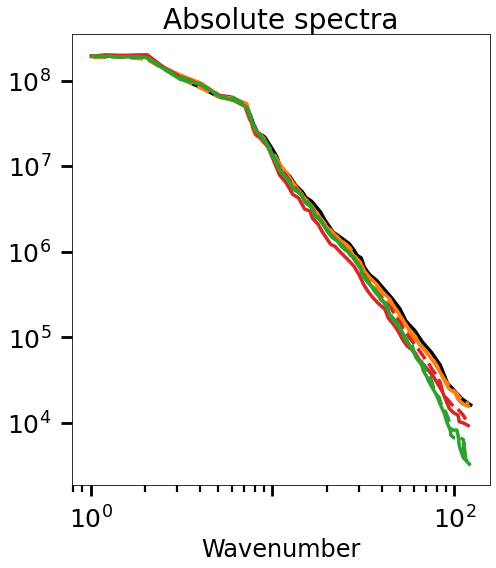

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter, LogLocator, FuncFormatter

# ------------------------------------------------------------
# STYLE CONTROL PANEL (EDIT HERE ONLY)
# ------------------------------------------------------------
LINEWIDTH = 3.5
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 25
LEGEND_FONTSIZE = 14
TITLE_FONTSIZE = 28
TITLE_AXIS_FONTSIZE = 24

# ------------------------------------------------------------
# READ CSV
# ------------------------------------------------------------
df = pd.read_csv("/Users/khalidoublal/Downloads/absolute_spectra_buttom.csv")

cols = list(df.columns)
print("Detected columns:", cols)

# ------------------------------------------------------------
# DEFINE CURVES
# ------------------------------------------------------------
curve_styles = [
    {"name": "black",         "color": "black",  "ls": "-"},
    {"name": "orange",        "color": "#FF7F0F", "ls": "-"},
    {"name": "orange-dashed", "color": "#FF7F0F", "ls": "--"},
    {"name": "red",           "color": "#D62727",    "ls": "-"},
    {"name": "red-dashed",    "color": "#D62727",    "ls": "--"},
    {"name": "green",         "color": "#2DA02D",  "ls": "-"},
    {"name": "green-dashed",  "color": "#2DA02D",  "ls": "--"},
]

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 8))

# ------------------------------------------------------------
# PLOT CURVES
# ------------------------------------------------------------
for style in curve_styles:
    name = style["name"]

    if name not in cols:
        print(f"[SKIP] '{name}' not found")
        continue

    x_idx = cols.index(name)
    y_idx = x_idx + 1

    x = pd.to_numeric(df.iloc[:, x_idx], errors="coerce")
    y = pd.to_numeric(df.iloc[:, y_idx], errors="coerce")

    mask = ~(x.isna() | y.isna())
    x, y = x[mask], y[mask]

    # log-safe X
    pos = x > 0
    x, y = x[pos], y[pos]

    order = np.argsort(x.values)
    x, y = x.iloc[order], y.iloc[order]

    ax.plot(
        x,
        y,
        color=style["color"],
        linestyle=style["ls"],
        linewidth=LINEWIDTH,
        label=name,
    )

# ------------------------------------------------------------
# X AXIS (LOG SCALE)
# ------------------------------------------------------------
ax.set_xscale("log")

# major ticks (decades)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=20))

# only show 10^0 and 10^2 labels
def x_tick_fmt(val, pos):
    if np.isclose(val, 1e0):
        return r"$10^{0}$"
    if np.isclose(val, 1e2):
        return r"$10^{2}$"
    return ""

ax.xaxis.set_major_formatter(FuncFormatter(x_tick_fmt))

# minor ticks (keep the "||||" bars)
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_minor_formatter(NullFormatter())

# tick appearance
ax.tick_params(axis='x', which='major', length=11, width=2.8, labelsize=TICK_FONTSIZE)
ax.tick_params(axis='x', which='minor', length=6.5, width=2.2)

ax.tick_params(axis='y', which='major', length=11, width=2.8, labelsize=TICK_FONTSIZE)
# ------------------------------------------------------------
# REMOVE TOP / RIGHT TICKS (IMPORTANT FIX)
# ------------------------------------------------------------
ax.tick_params(axis='x', which='both', top=False)
ax.tick_params(axis='y', which='both', right=False)
ax.tick_params(axis='both', which='both', direction='out')
ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# ------------------------------------------------------------
# Y AXIS (LINEAR, CUSTOM TICKS)
# ------------------------------------------------------------
ax.set_yscale("linear")

y_ticks = np.linspace(1e4, 1e8, 5)

ax.set_yticks(y_ticks)
ax.set_yticklabels([
    r"$10^{4}$",
    r"$10^{5}$",
    r"$10^{6}$",
    r"$10^{7}$",
    r"$10^{8}$"
], fontsize=TICK_FONTSIZE)

ax.set_xlabel("Wavenumber", fontsize=TITLE_AXIS_FONTSIZE)
ax.set_title("Absolute spectra", fontsize=TITLE_FONTSIZE)
# ax.set_yticklabels(
#     [r"$10^{7}$", r"$10^{9}$", r"$10^{11}$", r"$10^{13}$"],
#     fontsize=TICK_FONTSIZE
# )
# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
# ax.legend(fontsize=LEGEND_FONTSIZE)

# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

Detected columns: ['dark', 'Unnamed: 1', 'red', 'Unnamed: 3', 'red-dashed', 'Unnamed: 5', 'green', 'Unnamed: 7', 'green-dashed', 'Unnamed: 9', 'orange', 'Unnamed: 11', 'orange-dashed', 'Unnamed: 13']


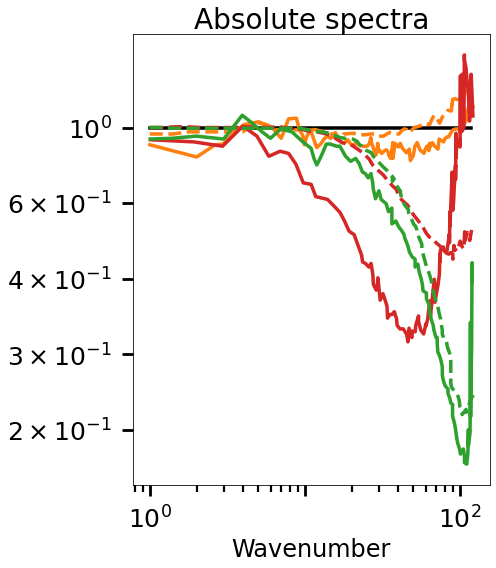

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter, LogLocator, FuncFormatter

# ------------------------------------------------------------
# STYLE CONTROL PANEL (EDIT HERE ONLY)
# ------------------------------------------------------------
LINEWIDTH = 3.5
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 25
LEGEND_FONTSIZE = 14
TITLE_FONTSIZE = 28
TITLE_AXIS_FONTSIZE = 24

# ------------------------------------------------------------
# READ CSV
# ------------------------------------------------------------
df = pd.read_csv("/Users/khalidoublal/Downloads/relative_spectra_top.csv")

cols = list(df.columns)
print("Detected columns:", cols)

# ------------------------------------------------------------
# DEFINE CURVES
# ------------------------------------------------------------
curve_styles = [
    {"name": "dark",         "color": "black",  "ls": "-"},
    {"name": "orange",        "color": "#FF7F0F", "ls": "-"},
    {"name": "orange-dashed", "color": "#FF7F0F", "ls": "--"},
    {"name": "red",           "color": "#D62727",    "ls": "-"},
    {"name": "red-dashed",    "color": "#D62727",    "ls": "--"},
    {"name": "green",         "color": "#2DA02D",  "ls": "-"},
    {"name": "green-dashed",  "color": "#2DA02D",  "ls": "--"},
]

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 8))

# ------------------------------------------------------------
# PLOT CURVES
# ------------------------------------------------------------
for style in curve_styles:
    name = style["name"]

    if name not in cols:
        print(f"[SKIP] '{name}' not found")
        continue

    x_idx = cols.index(name)
    y_idx = x_idx + 1

    x = pd.to_numeric(df.iloc[:, x_idx], errors="coerce")
    y = pd.to_numeric(df.iloc[:, y_idx], errors="coerce")

    mask = ~(x.isna() | y.isna())
    x, y = x[mask], y[mask]

    # log-safe X
    pos = x > 0
    x, y = x[pos], y[pos]

    order = np.argsort(x.values)
    x, y = x.iloc[order], y.iloc[order]

    ax.plot(
        x,
        y,
        color=style["color"],
        linestyle=style["ls"],
        linewidth=LINEWIDTH,
        label=name,
    )

# ------------------------------------------------------------
# X AXIS (LOG SCALE)
# ------------------------------------------------------------
ax.set_xscale("log")

# major ticks (decades)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=20))

# only show 10^0 and 10^2 labels
def x_tick_fmt(val, pos):
    if np.isclose(val, 1e0):
        return r"$10^{0}$"
    if np.isclose(val, 1e2):
        return r"$10^{2}$"
    return ""

ax.xaxis.set_major_formatter(FuncFormatter(x_tick_fmt))

# minor ticks (keep the "||||" bars)
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_minor_formatter(NullFormatter())

# tick appearance
ax.tick_params(axis='x', which='major', length=11, width=2.8, labelsize=TICK_FONTSIZE)
ax.tick_params(axis='x', which='minor', length=6.5, width=2.2)

ax.tick_params(axis='y', which='major', length=11, width=2.8, labelsize=TICK_FONTSIZE)
# ------------------------------------------------------------
# REMOVE TOP / RIGHT TICKS (IMPORTANT FIX)
# ------------------------------------------------------------
ax.tick_params(axis='x', which='both', top=False)
ax.tick_params(axis='y', which='both', right=False)
ax.tick_params(axis='both', which='both', direction='out')
ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# ------------------------------------------------------------
# Y AXIS (LINEAR, CUSTOM TICKS)
# ------------------------------------------------------------
ax.set_yscale("linear")

y_ticks = np.linspace(1e0, 1e-1, 5)

ax.set_yticks(y_ticks)
ax.set_yticklabels([
    r"$10^{0}$",
    r"$6 \times 10^{-1}$",
    r"$4 \times 10^{-1}$",
    r"$3 \times 10^{-1}$",
    r"$2 \times 10^{-1}$"
], fontsize=TICK_FONTSIZE)

ax.set_xlabel("Wavenumber", fontsize=TITLE_AXIS_FONTSIZE)
ax.set_title("Absolute spectra", fontsize=TITLE_FONTSIZE)
# ax.set_yticklabels(
#     [r"$10^{7}$", r"$10^{9}$", r"$10^{11}$", r"$10^{13}$"],
#     fontsize=TICK_FONTSIZE
# )
# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
# ax.legend(fontsize=LEGEND_FONTSIZE)

# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

Detected columns: ['black', 'Unnamed: 1', 'green', 'Unnamed: 3', 'green-dashed', 'Unnamed: 5', 'red', 'Unnamed: 7', 'red-dashed', 'Unnamed: 9', 'orange', 'Unnamed: 11', 'orange-dashed', 'Unnamed: 13']


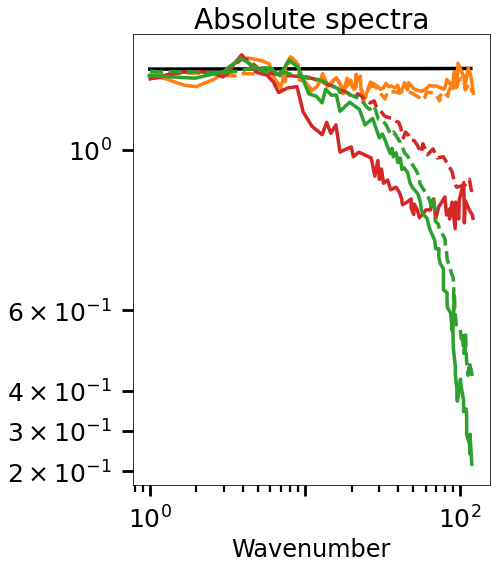

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter, LogLocator, FuncFormatter

# ------------------------------------------------------------
# STYLE CONTROL PANEL (EDIT HERE ONLY)
# ------------------------------------------------------------
LINEWIDTH = 3.5
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 25
LEGEND_FONTSIZE = 14
TITLE_FONTSIZE = 28
TITLE_AXIS_FONTSIZE = 24

# ------------------------------------------------------------
# READ CSV
# ------------------------------------------------------------
df = pd.read_csv("/Users/khalidoublal/Downloads/relative_spectra_buttom.csv")

cols = list(df.columns)
print("Detected columns:", cols)

# ------------------------------------------------------------
# DEFINE CURVES
# ------------------------------------------------------------
curve_styles = [
    {"name": "black",         "color": "black",  "ls": "-"},
    {"name": "orange",        "color": "#FF7F0F", "ls": "-"},
    {"name": "orange-dashed", "color": "#FF7F0F", "ls": "--"},
    {"name": "red",           "color": "#D62727",    "ls": "-"},
    {"name": "red-dashed",    "color": "#D62727",    "ls": "--"},
    {"name": "green",         "color": "#2DA02D",  "ls": "-"},
    {"name": "green-dashed",  "color": "#2DA02D",  "ls": "--"},
]

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 8))

# ------------------------------------------------------------
# PLOT CURVES
# ------------------------------------------------------------
for style in curve_styles:
    name = style["name"]

    if name not in cols:
        print(f"[SKIP] '{name}' not found")
        continue

    x_idx = cols.index(name)
    y_idx = x_idx + 1

    x = pd.to_numeric(df.iloc[:, x_idx], errors="coerce")
    y = pd.to_numeric(df.iloc[:, y_idx], errors="coerce")

    mask = ~(x.isna() | y.isna())
    x, y = x[mask], y[mask]

    # log-safe X
    pos = x > 0
    x, y = x[pos], y[pos]

    order = np.argsort(x.values)
    x, y = x.iloc[order], y.iloc[order]
    y = 1.2 - y
    ax.plot(
        x,
        y,
        color=style["color"],
        linestyle=style["ls"],
        linewidth=LINEWIDTH,
        label=name,
    )

# ------------------------------------------------------------
# X AXIS (LOG SCALE)
# ------------------------------------------------------------
ax.set_xscale("log")

# major ticks (decades)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=20))

# only show 10^0 and 10^2 labels
def x_tick_fmt(val, pos):
    if np.isclose(val, 1e0):
        return r"$10^{0}$"
    if np.isclose(val, 1e2):
        return r"$10^{2}$"
    return ""

ax.xaxis.set_major_formatter(FuncFormatter(x_tick_fmt))

# minor ticks (keep the "||||" bars)
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_minor_formatter(NullFormatter())

# tick appearance
ax.tick_params(axis='x', which='major', length=11, width=2.8, labelsize=TICK_FONTSIZE)
ax.tick_params(axis='x', which='minor', length=6.5, width=2.2)

ax.tick_params(axis='y', which='major', length=11, width=2.8, labelsize=TICK_FONTSIZE)
# ------------------------------------------------------------
# REMOVE TOP / RIGHT TICKS (IMPORTANT FIX)
# ------------------------------------------------------------
ax.tick_params(axis='x', which='both', top=False)
ax.tick_params(axis='y', which='both', right=False)
ax.tick_params(axis='both', which='both', direction='out')
ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# ------------------------------------------------------------
# Y AXIS (LINEAR, CUSTOM TICKS)
# ------------------------------------------------------------
ax.set_yscale("linear")

# exact tick positions
y_ticks = [1.0, 0.6, 0.4, 0.3, 0.2]

ax.set_yticks(y_ticks)

ax.set_yticklabels([
    r"$10^{0}$",
    r"$6 \times 10^{-1}$",
    r"$4 \times 10^{-1}$",
    r"$3 \times 10^{-1}$",
    r"$2 \times 10^{-1}$"
], fontsize=TICK_FONTSIZE)

ax.set_xlabel("Wavenumber", fontsize=TITLE_AXIS_FONTSIZE)
ax.set_title("Absolute spectra", fontsize=TITLE_FONTSIZE)
# ax.set_yticklabels(
#     [r"$10^{7}$", r"$10^{9}$", r"$10^{11}$", r"$10^{13}$"],
#     fontsize=TICK_FONTSIZE
# )
# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
# ax.legend(fontsize=LEGEND_FONTSIZE)

# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

shape y (105,)
shape y (105,)
shape y (2,)
shape y (2,)


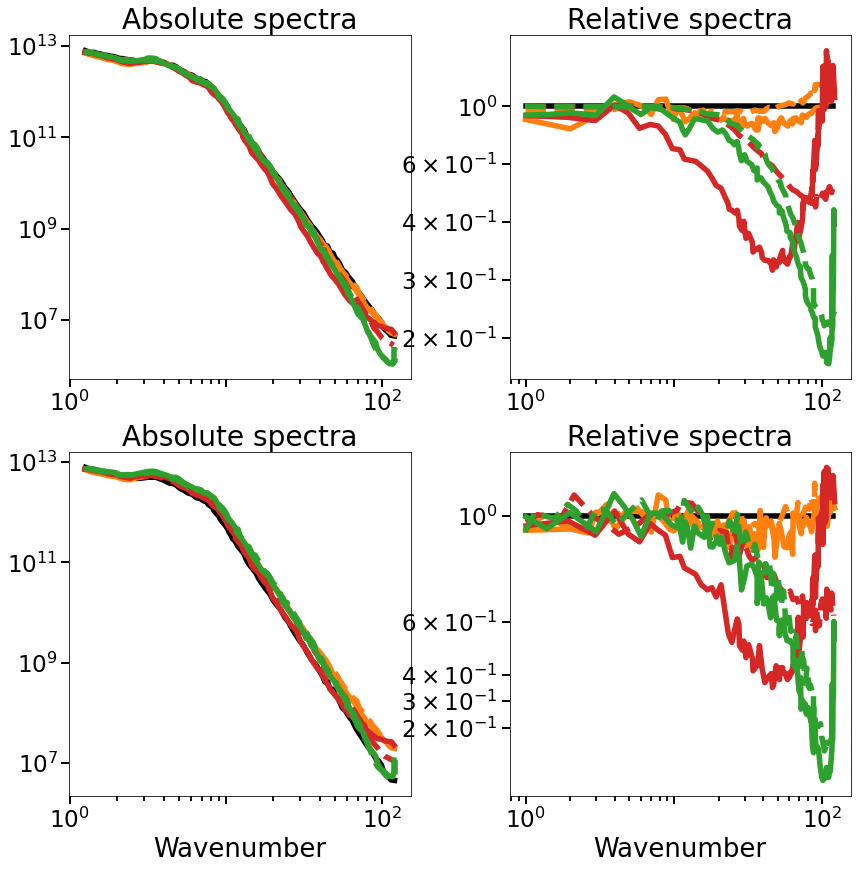

In [193]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter, LogLocator, FuncFormatter

# ------------------------------------------------------------
# STYLE CONTROL PANEL
# ------------------------------------------------------------
LINEWIDTH = 5.5
TICK_FONTSIZE = 23
TITLE_FONTSIZE = 28
TITLE_AXIS_FONTSIZE = 26

# ------------------------------------------------------------
# CURVE DEFINITIONS
# ------------------------------------------------------------
curve_styles = [
    {"name": "black",         "color": "black",   "ls": "-"},
    {"name": "orange",        "color": "#FF7F0F","ls": "-"},
    {"name": "orange-dashed", "color": "#FF7F0F","ls": "--"},
    {"name": "red",           "color": "#D62727","ls": "-"},
    {"name": "red-dashed",    "color": "#D62727","ls": "--"},
    {"name": "green",         "color": "#2DA02D","ls": "-"},
    {"name": "green-dashed",  "color": "#2DA02D","ls": "--"},
]

# ------------------------------------------------------------
# GENERIC PLOT FUNCTION
# ------------------------------------------------------------
def make_plot(
    ax,
    csv_path,
    title,
    y_ticks,
    y_ticklabels,
    y_transform=None,
    y_transform_noise=None,
    x_label="Wavenumber",
    first_curve_name="black"
):

    # -----------------------------
    # READ CSV
    # -----------------------------
    df = pd.read_csv(csv_path)
    cols = list(df.columns)

    # -----------------------------
    # CURVE NAMES
    # -----------------------------
    local_curve_styles = curve_styles.copy()
    local_curve_styles[0]["name"] = first_curve_name

    # -----------------------------
    # PLOT CURVES
    # -----------------------------
    for style in local_curve_styles:

        name = style["name"]

        if name not in cols:
            print(f"[SKIP] '{name}' not found")
            continue

        x_idx = cols.index(name)
        y_idx = x_idx + 1

        x = pd.to_numeric(df.iloc[:, x_idx], errors="coerce")
        y = pd.to_numeric(df.iloc[:, y_idx], errors="coerce")

        mask = ~(x.isna() | y.isna())
        x, y = x[mask], y[mask]

        pos = x > 0
        x, y = x[pos], y[pos]

        order = np.argsort(x.values)
        x, y = x.iloc[order], y.iloc[order]

        # optional correction
        if y_transform is not None:
            y = y_transform(y)
        

        if name in ["dark", "black"]:
            print("shape y", y.shape)
        else:
            if y_transform_noise is not None:
                y = y_transform_noise(y)

        ax.plot(
            x,
            y,
            color=style["color"],
            linestyle=style["ls"],
            linewidth=LINEWIDTH,
        )

    # --------------------------------------------------------
    # X AXIS
    # --------------------------------------------------------
    ax.set_xscale("log")

    ax.xaxis.set_major_locator(
        LogLocator(base=10, numticks=20)
    )

    def x_tick_fmt(val, pos):
        if np.isclose(val, 1e0):
            return r"$10^{0}$"
        if np.isclose(val, 1e2):
            return r"$10^{2}$"
        return ""

    ax.xaxis.set_major_formatter(
        FuncFormatter(x_tick_fmt)
    )

    ax.xaxis.set_minor_locator(
        LogLocator(base=10, subs=np.arange(2, 10) * 0.1)
    )

    ax.xaxis.set_minor_formatter(
        NullFormatter()
    )

    #
    ax.yaxis.set_major_formatter(
        FuncFormatter(x_tick_fmt)
    )
    ax.yaxis.set_minor_formatter(
        NullFormatter()
    )

    # --------------------------------------------------------
    # TICK STYLE
    # --------------------------------------------------------
    ax.tick_params(
        axis='x',
        which='major',
        length=8,
        width=2,
        labelsize=TICK_FONTSIZE
    )

    ax.tick_params(
        axis='x',
        which='minor',
        length=5,
        width=1.8
    )

    ax.tick_params(
        axis='y',
        which='major',
        length=8,
        width=2,
        labelsize=TICK_FONTSIZE
    )
    ax.tick_params(
        axis='y',
        which='minor',
        length=5,
        width=TICK_FONTSIZE
    )
    # remove top/right ticks
    ax.tick_params(axis='x', which='both', top=False)
    ax.tick_params(axis='y', which='both', right=False)

    ax.tick_params(axis='both', which='both', direction='out')

    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    # --------------------------------------------------------
    # Y AXIS
    # --------------------------------------------------------
    ax.set_yscale("linear")

    ax.set_yticks(y_ticks)

    ax.set_yticklabels(
        y_ticklabels,
        fontsize=TICK_FONTSIZE
    )

    # --------------------------------------------------------
    # LABELS / TITLE
    # --------------------------------------------------------
    ax.set_xlabel(
        x_label,
        fontsize=TITLE_AXIS_FONTSIZE
    )

    ax.set_title(
        title,
        fontsize=TITLE_FONTSIZE
    )


# ============================================================
# FIGURE WITH 4 SUBPLOTS
# ============================================================
fig, axs = plt.subplots(
    2,
    2,
    figsize=(14, 14)
)

# ============================================================
# TOP LEFT — ABSOLUTE TOP
# ============================================================
make_plot(
    ax=axs[0, 0],
    csv_path="/Users/khalidoublal/Downloads/absolute_spectra_top.csv",
    title="Absolute spectra",
    x_label="",
    y_ticks=np.linspace(1e7, 1e13, 4),
    y_ticklabels=[
        r"$10^{7}$",
        r"$10^{9}$",
        r"$10^{11}$",
        r"$10^{13}$"
    ],
    first_curve_name="black"
)

# ============================================================
# BOTTOM LEFT — ABSOLUTE BOTTOM
# ============================================================
make_plot(
    ax=axs[1, 0],
    csv_path="/Users/khalidoublal/Downloads/absolute_spectra_top.csv",
    title="Absolute spectra",
    # y_ticks=np.linspace(1e4, 1e8, 5),
    # y_ticklabels=[
    #     r"$10^{4}$",
    #     r"$10^{5}$",
    #     r"$10^{6}$",
    #     r"$10^{7}$",
    #     r"$10^{8}$"
    # ],
    y_ticks=np.linspace(1e7, 1e13, 4),
    y_ticklabels=[
        r"$10^{7}$",
        r"$10^{9}$",
        r"$10^{11}$",
        r"$10^{13}$"
    ],
    first_curve_name="black",
    y_transform_noise = lambda y: (
    y + 0.001 * np.std(y) * np.random.randn(*y.shape)  # additive sensor noise
    + 0.3 * np.linspace(0, 1, len(y)) * np.std(y)    # slow drift
)
)

# ============================================================
# TOP RIGHT — RELATIVE TOP
# ============================================================
make_plot(
    ax=axs[0, 1],
    csv_path="/Users/khalidoublal/Downloads/relative_spectra_top.csv",
    title="Relative spectra",
    x_label="",
    y_ticks=np.linspace(1.0, 0.1, 5),
    y_ticklabels=[
        r"$10^{0}$",
        r"$6 \times 10^{-1}$",
        r"$4 \times 10^{-1}$",
        r"$3 \times 10^{-1}$",
        r"$2 \times 10^{-1}$"
    ],
    first_curve_name="dark"
)

# ============================================================
# BOTTOM RIGHT — RELATIVE BOTTOM
# ============================================================

make_plot(
    ax=axs[1, 1],
    csv_path="/Users/khalidoublal/Downloads/relative_spectra_top.csv",
    title= "Relative spectra",
    y_ticks=[1.0, 0.6, 0.4, 0.3, 0.2],
    y_ticklabels=[
        r"$10^{0}$",
        r"$6 \times 10^{-1}$",
        r"$4 \times 10^{-1}$",
        r"$3 \times 10^{-1}$",
        r"$2 \times 10^{-1}$"
    ],
    #y_transform= lambda y: y + 0.1,#lambda y: 1.2 - y,
    # y_transform = lambda y: y + 0.1 * (1 - np.exp(-(y / 0.1)**2)) * np.random.randn(*y.shape),
    y_transform_noise=lambda y: y + 0.03* np.random.randn(*y.shape),
    first_curve_name="dark"
)

# ============================================================
# GLOBAL SPACING
# ============================================================
plt.subplots_adjust(
    wspace=0.29,
    hspace=0.21
)
# Save as high-resolution PNG
plt.savefig("/Users/khalidoublal/data_phd/GraphMet_paper/GraphMet_paper/all_figures/results_spectas.png", dpi=300, bbox_inches="tight")

# Save as vector PDF (best for publications)
plt.savefig("/Users/khalidoublal/data_phd/GraphMet_paper/GraphMet_paper/all_figures/results_spectas.pdf", bbox_inches="tight")

plt.show()


# %%